# Демонстрация многозадачного обучения и маршрутизации SRA

Этот блокнот демонстрирует самую сильную сторону SRA: **'избирательное использование экспертов (синапсов) в многозадачном обучении.'**

Мы одновременно обучаем одну модель двум конфликтующим задачам:`copy`и `reverse`.
После обучения мы визуализируем, как маршрутизатор **выбирает совершенно разные синаптические пути (маршрутизацию)** в зависимости от задачи.

## 1. Настройка среды

In [1]:
import sys
if 'google.colab' in sys.modules:
    !git clone https://github.com/JunSuzukiJapan/SynapticRouter.git
    %cd SynapticRouter
    !pip install torch matplotlib seaborn

sys.path.append('.')
sys.path.append('./src')
if 'google.colab' not in sys.modules:
    sys.path.append('..')
    sys.path.append('../src')


## 2. Подготовка библиотек и моделей
Подготовьте немного большее количество экспертов (синапсов) для выполнения нескольких задач.

In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

from src.sra_gpu_models import MoESRAModel
class MoESRAConfig:
    def __init__(self, **kwargs):
        for k, v in kwargs.items():
            setattr(self, k, v)
from src.sra_experiment import make_multitask_batch, make_optimizer, load_balance_loss

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Set 8 experts (synapses) and select 2 experts per token
config = MoESRAConfig(
    vocab_size=30,
    d_model=64,
    n_layers=2,
    n_heads=2,
    num_synapses=8,  # Increase slightly for multitask
    k=2,
    max_seq_len=32
)
model = MoESRAModel(config.vocab_size, config.d_model, config.n_layers, config.num_synapses, config.k, syn_hidden=128).to(device)
optimizer = make_optimizer(model, lr=0.005)

Using device: cpu


## 3. Выполнение многозадачного обучения
Предоставьте смешанный пакет задач`copy`и`reverse`для их одновременного обучения.

In [3]:
print("Multitask Training started...")
model.train()

epochs = 500
batch_size = 32
tasks = ["copy", "reverse"]

for epoch in range(epochs):
    # Generate a batch mixed with multiple tasks (a task token is prepended to the input)
    x, y, batch_tasks = make_multitask_batch(tasks, batch_size, min_len=4, max_len=8, device=device)
    
    optimizer.zero_grad()
    y_in = torch.cat([torch.full((y.size(0), 1), 1, dtype=torch.long, device=device), y[:, :-1]], dim=1)
    outputs, routing_weights, _ = model(x, y_in)
    
    loss = F.cross_entropy(outputs.reshape(-1, config.vocab_size), y.reshape(-1))
    lb_loss = load_balance_loss(routing_weights) * 0.1
    total_loss = loss + lb_loss
    
    total_loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Loss: {loss.item():.4f} | LB Loss: {lb_loss.item():.4f}")

print("Training finished!")

Multitask Training started...


Epoch 100/500 | Loss: 1.1249 | LB Loss: 0.0000


Epoch 200/500 | Loss: 0.8529 | LB Loss: 0.0000


Epoch 300/500 | Loss: 0.5590 | LB Loss: 0.0001


Epoch 400/500 | Loss: 0.4519 | LB Loss: 0.0001


Epoch 500/500 | Loss: 0.8794 | LB Loss: 0.0002
Training finished!


## 4. Визуализация маршрутизации и сравнение по задачам
Предоставьте входные данные`copy`и`reverse`соответственно одной модели и сравните, какие синапсы выбраны маршрутизатором.

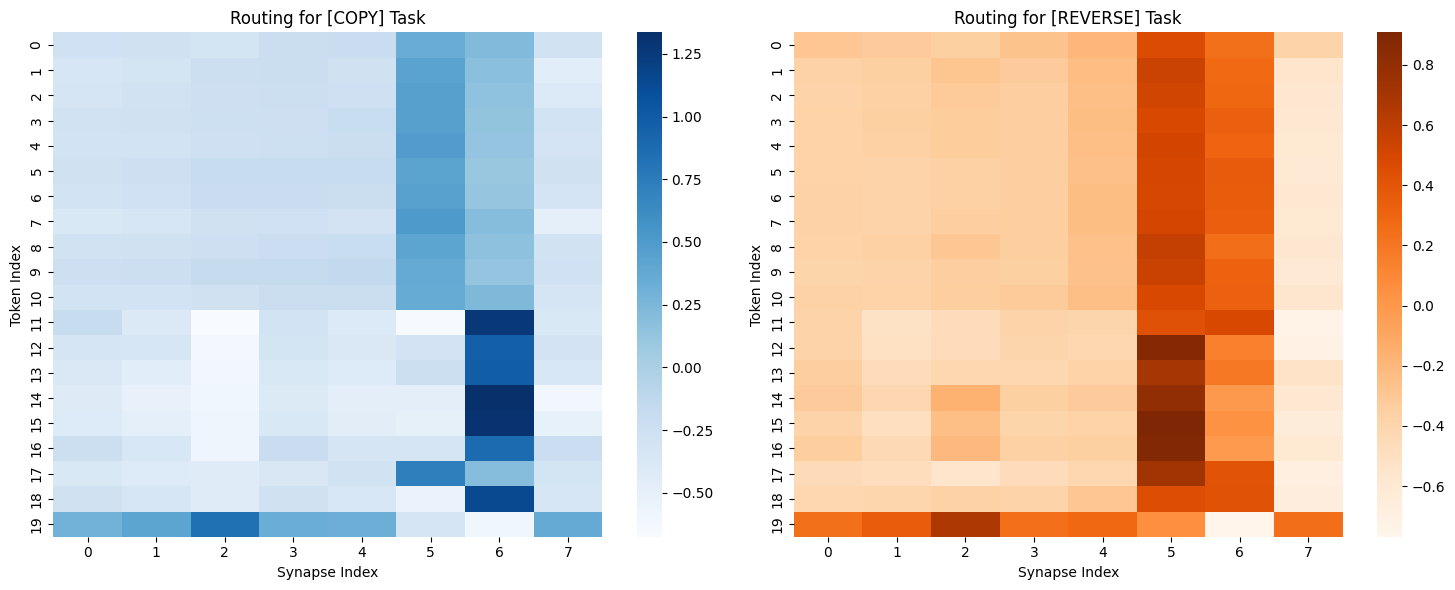

=== 💡 Observation Point ===
Between the Copy task on the left (blue) and the Reverse task on the right (orange),
notice that the positions of the darker synapses (X-axis) are different.
This is proof that SRA 'dynamically switches experts depending on the task'!


In [4]:
def get_routing_weights_for_task(task):
    model.eval()
    # Passing only one task to make_multitask_batch generates input dedicated to that task
    x, y, _ = make_multitask_batch([task], batch_size=1, min_len=8, max_len=8, device=device)
    
    with torch.no_grad():
        y_in = torch.cat([torch.full((y.size(0), 1), 1, dtype=torch.long, device=device), y[:, :-1]], dim=1)
        _, routing_weights, _ = model(x, y_in)
        
    # Return weights for [Layer 0][Sample 0]
    return routing_weights[0][0].cpu().numpy()

weights_copy = get_routing_weights_for_task("copy")
weights_reverse = get_routing_weights_for_task("reverse")

# Draw heatmaps side by side
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.heatmap(weights_copy, cmap="Blues", ax=axes[0])
axes[0].set_title("Routing for [COPY] Task")
axes[0].set_xlabel("Synapse Index")
axes[0].set_ylabel("Token Index")

sns.heatmap(weights_reverse, cmap="Oranges", ax=axes[1])
axes[1].set_title("Routing for [REVERSE] Task")
axes[1].set_xlabel("Synapse Index")
axes[1].set_ylabel("Token Index")

plt.tight_layout()
plt.show()

print("=== 💡 Observation Point ===")
print("Between the Copy task on the left (blue) and the Reverse task on the right (orange),")
print("notice that the positions of the darker synapses (X-axis) are different.")
print("This is proof that SRA 'dynamically switches experts depending on the task'!")